# Real Benchmark Demo (Unified Pipeline)
Минимальный ноутбук для запуска `real_gap_vrp`, `real_gap_vrp_alns`, `real_milp`, `real_genetic`, `real_gap_vrp_saa`
через единый pipeline-слой: **dataset -> constraints builder -> solver -> unified metrics**.

Поддерживаются два режима:
- быстрый профиль U50 (`day_load_profiles/u50/fast_uniform`)
- любой JSON из `clean_full_enriched/sweep_7task_7agents`


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import pandas as pd


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Repo root not found")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 140)
print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: /Users/igoreshka/Desktop/Optimization-of-flows


In [2]:
from flowopt.demo import prepare_context_from_dataset_path, prepare_u50_fast_uniform_context

# Минимум внешних параметров: выбираем только режим и (опционально) путь к датасету.
DATASET_MODE = "u50_fast_uniform_repo_data"  # u50_fast_uniform_repo_data | u50_fast_uniform | clean_full_enriched_sweep

DOWNSCALE_FACTOR = 10.0
SEED = 42
FORCE_REBUILD = False

REPO_DATASET_PATH = (
    REPO_ROOT
    / "demo"
    / "data"
    / "u50_fast_uniform"
    / "dataset_real_spb_day_u50_fast_f10.json"
)

REPO_SUMMARY_PATH = (
    REPO_ROOT
    / "demo"
    / "data"
    / "u50_fast_uniform"
    / "summary_real_spb_day_u50_fast_f10.json"
)

SWEEP_DATASET_PATH = (
    REPO_ROOT
    / "src"
    / "data"
    / "real"
    / "clean_full_enriched"
    / "sweep_7task_7agents"
    / "dataset_real_spb_clean_full_enriched_t005_a005.json"
)

if DATASET_MODE == "u50_fast_uniform_repo_data":
    context = prepare_context_from_dataset_path(
        dataset_path=REPO_DATASET_PATH,
        summary_path=REPO_SUMMARY_PATH,
        output_subdir="u50_fast_uniform_repo_data",
    )
elif DATASET_MODE == "u50_fast_uniform":
    context = prepare_u50_fast_uniform_context(
        downscale_factor=DOWNSCALE_FACTOR,
        seed=SEED,
        force_rebuild=FORCE_REBUILD,
    )
elif DATASET_MODE == "clean_full_enriched_sweep":
    context = prepare_context_from_dataset_path(
        dataset_path=SWEEP_DATASET_PATH,
        output_subdir="clean_full_enriched_sweep_demo",
    )
else:
    raise ValueError(f"Unknown DATASET_MODE={DATASET_MODE}")

print("DATASET_MODE:", DATASET_MODE)
print("DATASET_PATH:", context.dataset_path)
print("SUMMARY_PATH:", context.summary_path)
print("OUTPUT_DIR  :", context.output_dir)
if context.summary:
    print("summary keys:", sorted(context.summary.keys())[:12])

pd.DataFrame([context.counts])


DATASET_MODE: u50_fast_uniform_repo_data
DATASET_PATH: /Users/igoreshka/Desktop/Optimization-of-flows/demo/data/u50_fast_uniform/dataset_real_spb_day_u50_fast_f10.json
SUMMARY_PATH: /Users/igoreshka/Desktop/Optimization-of-flows/demo/data/u50_fast_uniform/summary_real_spb_day_u50_fast_f10.json
OUTPUT_DIR  : /Users/igoreshka/Desktop/Optimization-of-flows/demo/local/u50_fast_uniform_repo_data/dataset_real_spb_day_u50_fast_f10
summary keys: ['after', 'before', 'downscale_factor', 'output_dataset', 'required_agents_by_depot', 'required_hours_by_depot', 'seed', 'selected_agents_by_depot', 'selected_tasks_by_depot', 'source_dataset']


,nodes,edges,agents,tasks,objects,sources
0,46730,127100,50,32,5,32


In [ ]:
from flowopt.demo import run_u50_fast_uniform_benchmark, benchmark_main_table

SHOW_ALGO_PROGRESS = True
SHOW_SOLVER_DETAILS = False
REQUIRE_FULL_ASSIGNMENT = False

benchmark_df, artifact_path = run_u50_fast_uniform_benchmark(
    context,
    show_algo_progress=SHOW_ALGO_PROGRESS,
    show_solver_details=SHOW_SOLVER_DETAILS,
    require_full_assignment=REQUIRE_FULL_ASSIGNMENT,
)

print("Saved:", artifact_path)
main_table = benchmark_main_table(benchmark_df)
main_table


[+    0.0s] GAP-VRP: START
[+    1.5s] [real_gap_vrp] dataset profile: generic_real
[+    1.5s] [real_gap_vrp] constraints: edge_vt=True, agent_volume=False, object_caps_m=True, object_caps_v=False
[+    1.5s] [real_gap_vrp] build nx graph
[+    1.7s] [real_gap_vrp] solver start
[+    1.7s] [real_gap_vrp] [GAP-VRP] start: GAP-Lagrangean + VRP(NN+2opt) [step1=dataset]
[+    1.7s] [real_gap_vrp] [GAP-VRP] step1: task generation
[+    1.7s] [real_gap_vrp] [GAP-VRP] step1 done in 0.0s, tasks=32
[+    1.7s] [real_gap_vrp] [GAP-VRP] step2: GAP Lagrangean, iter=20
[+    1.7s] [real_gap_vrp] [GAP-LR] prepare matrices: agents=50, tasks=32, max_iter=20
[+    5.9s] [real_gap_vrp] [GAP-LR] precompute costs: 5/50 agents
[+    7.0s] [real_gap_vrp] [GAP-LR] precompute costs: 10/50 agents
[+    7.0s] [real_gap_vrp] [GAP-LR] precompute costs: 15/50 agents
[+    7.0s] [real_gap_vrp] [GAP-LR] precompute costs: 20/50 agents
[+    7.0s] [real_gap_vrp] [GAP-LR] precompute costs: 25/50 agents
[+    7.8s] [re

In [5]:
from flowopt.demo import benchmark_detail_table

detail_table = benchmark_detail_table(benchmark_df)
detail_table


,algorithm,checks,step1_method,gap_iter,used_agents,time_limit_sec,unassigned_penalty,population_size,generations,generations_requested,...,alns_base_objective,alns_best_objective,alns_gain,saa_sample_size,saa_iterations,saa_route_max_size,saa_seed,saa_log_every,saa_route_pool_size,saa_assembled_route_count
0,real_genetic,"{'hard_constraints_ok': True, 'daily_limits_ok': True, 'reachability_ok': True, 'all_tasks_assigned': True, 'mno_coverage_ok': True, 'al...",NaN,NaN,NaN,NaN,NaN,20.0,20.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,real_milp,"{'hard_constraints_ok': True, 'daily_limits_ok': True, 'reachability_ok': True, 'all_tasks_assigned': True, 'mno_coverage_ok': True, 'al...",NaN,NaN,NaN,90.0,10000000.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,real_gap_vrp_alns,"{'hard_constraints_ok': True, 'daily_limits_ok': True, 'reachability_ok': True, 'all_tasks_assigned': True, 'mno_coverage_ok': True, 'al...",dataset,20.0,50.0,NaN,NaN,NaN,NaN,NaN,...,3292.592,3292.592,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,real_gap_vrp,"{'hard_constraints_ok': True, 'daily_limits_ok': True, 'reachability_ok': True, 'all_tasks_assigned': True, 'mno_coverage_ok': True, 'al...",dataset,20.0,50.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,real_gap_vrp_saa,"{'hard_constraints_ok': True, 'daily_limits_ok': True, 'reachability_ok': True, 'all_tasks_assigned': True, 'mno_coverage_ok': True, 'al...",dataset,20.0,50.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,12.0,60.0,8.0,42.0,10.0,120.0,12.0


In [6]:
from flowopt.demo import render_solution_map_for_algorithm
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
SCHEDULE_ALGO = "real_milp"  # real_gap_vrp | real_gap_vrp_alns | real_gap_vrp_saa | real_milp | real_genetic
MAP_SHOW_SOLVER_PROGRESS = False
render_info = render_solution_map_for_algorithm(
    context,
    algorithm=SCHEDULE_ALGO,
    show_solver_progress=MAP_SHOW_SOLVER_PROGRESS,
)
render_info


{'algorithm': 'real_milp',
 'assigned_routes': 32,
 'unassigned': 0,
 'active_agents': 23,
 'feasible': True,
 'map_path': PosixPath('/Users/igoreshka/Desktop/Optimization-of-flows/demo/local/u50_fast_uniform/f10/schedule_map_real_milp_f10.png'),
 'plan_path': PosixPath('/Users/igoreshka/Desktop/Optimization-of-flows/demo/local/u50_fast_uniform/f10/schedule_plan_real_milp_f10.json')}

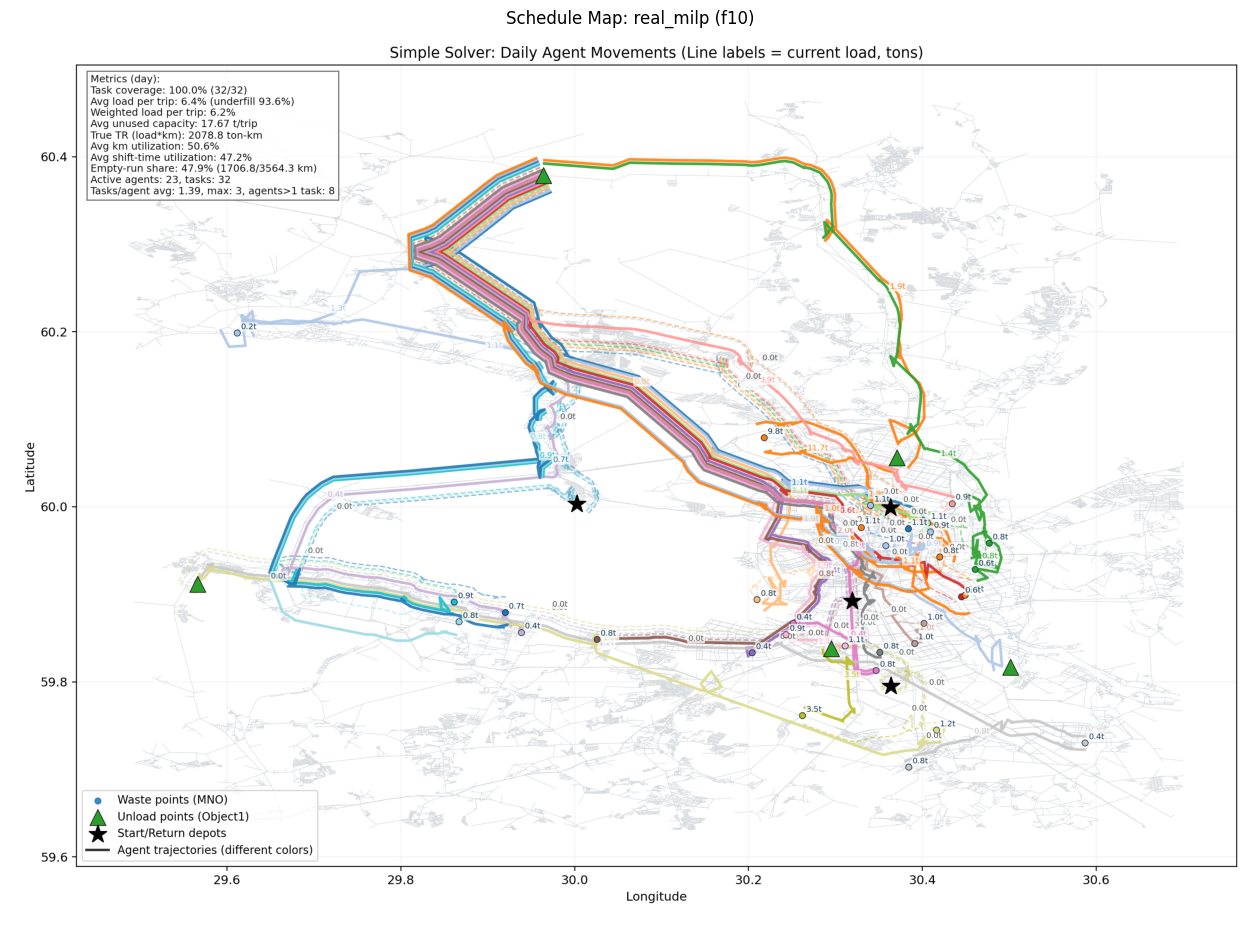

In [7]:
img = mpimg.imread(render_info["map_path"])
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis("off")
plt.title(f"Schedule Map: {render_info['algorithm']} ({context.factor_tag})")
plt.show()


In [ ]:
from flowopt.demo import render_per_agent_maps_for_algorithm

SAVE_PER_AGENT_MAPS = True
PER_AGENT_MAX = None  # например 10, чтобы ограничить число картинок

if SAVE_PER_AGENT_MAPS:
    per_agent_info = render_per_agent_maps_for_algorithm(
        context,
        algorithm=SCHEDULE_ALGO,
        show_solver_progress=False,
        max_agents=PER_AGENT_MAX,
    )
    print("Saved per-agent maps:", per_agent_info["saved_agents"], "->", per_agent_info["output_dir"])
    per_agent_info


In [ ]:
from flowopt.reporting import solution_breakdown_tables
from IPython.display import Markdown, display

MAX_AGENTS_TO_SHOW = 30
MAX_TASK_IDS_IN_CELL = 12
MAX_TASK_ROWS_TO_SHOW = 300

for _, row in benchmark_df.iterrows():
    algo = row.get("algorithm", "unknown")
    tables = solution_breakdown_tables(
        row,
        max_agents=MAX_AGENTS_TO_SHOW,
        max_task_ids=MAX_TASK_IDS_IN_CELL,
    )

    display(Markdown(f"### {algo}: решение по агентам"))
    display(tables["summary"])

    if tables["agents"].empty:
        print("No active agents in solution")
        continue

    display(tables["agents"])
    display(Markdown(f"**{algo}: задача -> агент (первые {MAX_TASK_ROWS_TO_SHOW} строк)**"))
    display(tables["tasks"].head(MAX_TASK_ROWS_TO_SHOW))
